In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
df = pd.read_csv("./wine_data.csv", header=None, usecols=[0, 1, 2])
df.columns = ["Class label", "Alcohol", "Malic acid"]
df.describe()

,Class label,Alcohol,Malic acid
count,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348
std,0.775035,0.811827,1.117146
min,1.000000,11.030000,0.740000
25%,1.000000,12.362500,1.602500
50%,2.000000,13.050000,1.865000
75%,3.000000,13.677500,3.082500
max,3.000000,14.830000,5.800000


<Axes: xlabel='Malic acid', ylabel='Density'>

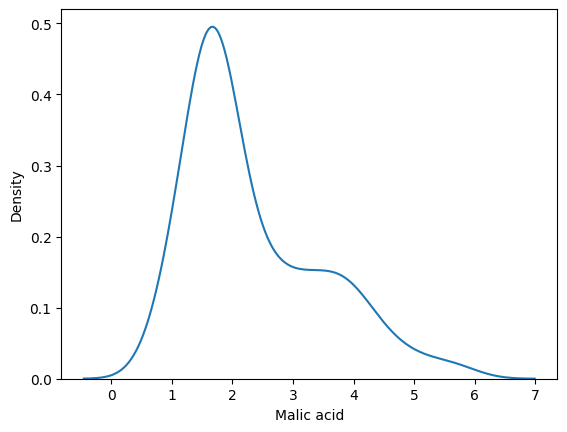

In [30]:
sns.kdeplot(x=df["Malic acid"])

### Train Test Split

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.drop("Class label", axis=1), df["Class label"], test_size=0.3
)
X_train.shape, X_test.shape

((124, 2), (54, 2))

In [32]:
from sklearn.preprocessing import MinMaxScaler, MaxAbsScaler

scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
# Convert from numpy arrays -> DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [34]:
np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.3,0.2
50%,0.5,0.2
75%,0.7,0.4
max,1.0,1.0


Text(0.5, 1.0, 'After Scaling (X_train_scaled)')

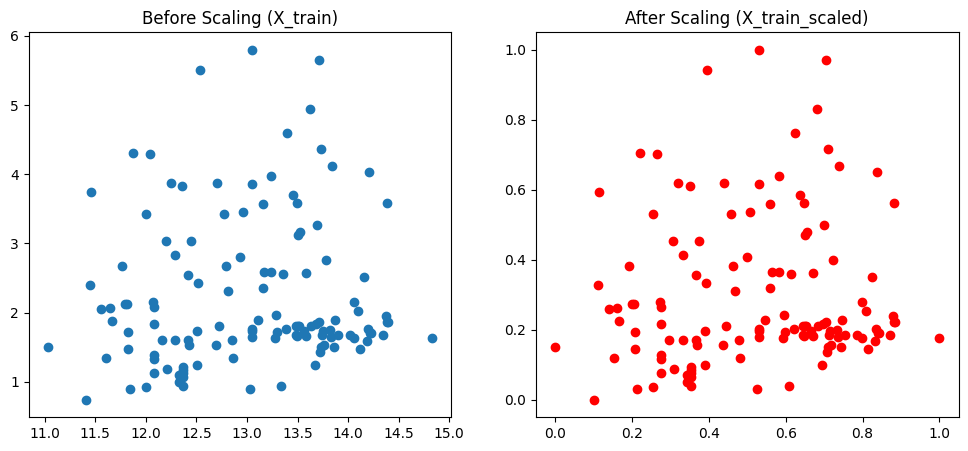

In [35]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train["Alcohol"], X_train["Malic acid"])
ax1.set_title("Before Scaling (X_train)")

ax2.scatter(X_train_scaled["Alcohol"], X_train_scaled["Malic acid"], color="red")
ax2.set_title("After Scaling (X_train_scaled)")